# Sentiment Analysis and Topic Modeling of US Presidential Debates from 1960 to 2024

### Daniel Henke (176182), Sven Kurth (175866), Margherita Grosso (176786), Luca Gudi (xxx)

## Install and Load Packages

In [1]:
!pip install -q gensim 
!pip install -q nltk
!pip install -q spacy
!python -m spacy download en_core_web_sm --quiet
!pip install -q transformers
!pip install -q torch
!pip install -q hf_xet
!pip install -q numpy
%pip uninstall -y gensim numpy > /dev/null 2>&1
%pip install -q numpy==1.26.4
!pip install tensorflow
!pip install seaborn

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import WordNetLemmatizer, SnowballStemmer
from nltk.stem.porter import *
from nltk.tokenize import TreebankWordTokenizer
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from matplotlib.patches import Patch
import torch
import hf_xet
import spacy

In [14]:
import os

In [3]:
import pandas as pd
import nltk
from transformers import pipeline
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
import torch
import numpy as np

import torch
import torch.nn as nn
from scipy.special import softmax
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Completely remove incompatible packages
%pip uninstall -y gensim scipy numpy

# Install known-compatible versions
%pip install numpy==1.26.4 scipy==1.10.1 gensim==4.3.2

Found existing installation: scipy 1.13.1
Uninstalling scipy-1.13.1:
  Successfully uninstalled scipy-1.13.1
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10;

In [5]:
!pip install gensim

  Using cached gensim-4.3.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached gensim-4.3.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.6 MB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached scipy-1.13.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gensim]2m2/3 [gensim]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [6]:
import gensim
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel, LdaSeqModel
from collections import Counter

# Load and Prepare Data

## Create Dataframe for US Debates from 1960 to 2020 the Dataset from Kaggle

### Define Directory

In [7]:
DATA_DIRECTORY = "data_dir"

### Meta Data

In [8]:
INCUMBENT_PAIRS = {
    ("ford", "1976"), ("carter", "1980"), ("reagan", "1984"), ("bush", "1984"),
    ("bush", "1992"), ("quayle", "1992"), ("clinton", "1996"), ("gore", "1996"),
    ("bush", "2004"), ("cheney", "2004"), ("obama", "2012"), ("biden", "2012"),
    ("trump", "2020"), ("pence", "2020")
}

WINNER_PAIRS = {
    ("kennedy", "1960"), ("carter", "1976"), ("reagan", "1980"), ("bush", "1980"),
    ("reagan", "1984"), ("bush", "1984"), ("bush", "1988"), ("quayle", "1988"),
    ("clinton", "1992"), ("gore", "1992"), ("clinton", "1996"), ("gore", "1996"),
    ("bush", "2000"), ("cheney", "2000"), ("bush", "2004"), ("cheney", "2004"),
    ("obama", "2008"), ("biden", "2008"), ("obama", "2012"), ("biden", "2012"),
    ("trump", "2016"), ("pence", "2016"), ("biden", "2020"), ("harris", "2020")
}

CANDIDATES = {
    # Presidential
    "kennedy": "Democratic", "nixon": "Republican", "ford": "Republican",
    "carter": "Democratic", "reagan": "Republican", "anderson": "Independent",
    "mondale": "Democratic", "bush": "Republican", "dukakis": "Democratic",
    "clinton": "Democratic", "perot": "Independent", "dole": "Republican",
    "gore": "Democratic", "kerry": "Democratic", "obama": "Democratic",
    "mccain": "Republican", "romney": "Republican", "trump": "Republican",
    "biden": "Democratic",

    # Vice-Presidential
    "ferraro": "Democratic", "quayle": "Republican", "bentsen": "Democratic",
    "kemp": "Republican", "stockdale": "Independent", "lieberman": "Democratic", "cheney": "Republican",
    "edwards": "Democratic", "palin": "Republican", "ryan": "Republican",
    "kaine": "Democratic", "pence": "Republican", "harris": "Democratic",
    "vance": "Republican"
}

CANDIDATE_FIRST_NAMES = {
    "Kennedy": "John",
    "Humphrey": "Hubert",
    "McGovern": "George",
    "Carter": "Jimmy",
    "Mondale": "Walter",
    "Dukakis": "Michael",
    "Clinton Bill": "Bill",
    "Gore": "Al",
    "Kerry": "John",
    "Obama": "Barack",
    "Clinton Hillary": "Hillary",
    "Biden": "Joe",
    "Nixon": "Richard",
    "Goldwater": "Barry",
    "Ford": "Gerald",
    "Reagan": "Ronald",
    "Bush Sr": "George",  
    "Bush Jr": "George",
    "Dole": "Bob",
    "Mccain": "John",
    "Romney": "Mitt",
    "Trump": "Donald",
    "Kemp": "Jack",
    "Perot": "Ross",
    "Anderson": "John",
    "Ferraro": "Geraldine",
    "Quayle": "Dan",
    "Lieberman": "Joe",
    "Edwards": "John",
    "Palin": "Sarah",
    "Ryan": "Paul",
    "Pence": "Mike",
    "Harris": "Kamala",
    "Cheney": "Dick",
    "Bentsen": "Lloyd",
    "Kaine": "Tim",
    "Stockdale": "James",
    "Walz": "Tim",
    "Vance": "J.D."
}

VP_CORRECTIONS = ["2000-10-11", "2008-09-26", "2012-10-03"]

### Functions for Data Cleaning

In [9]:
def normalize_last_name(full_name):
    """Extracts the last name and applies capitalization."""
    if not full_name or full_name == "UNKNOWN":
        return "UNKNOWN"
    return full_name.strip().split()[-1].capitalize()

def fix_duplicate_names(last_name, year, is_candidate, party):
    """Fixes duplicate names for specific cases."""
    if last_name.lower() == "bush":
        last_name = "Bush Sr" if str(year) in ["1984", "1988", "1992"] else "Bush Jr"
    elif last_name.lower() == "clinton":
        last_name = "Clinton Hillary" if str(year) == "2016" else "Clinton Bill"
    elif last_name.lower() == "edwards" and str(year) == "1960":
        is_candidate = False
        party = None
    return last_name, is_candidate, party

### Functions for Data Enrichment

In [10]:
def check_incumbent(last_name, year):
    """Returns True if candidate is incumbent that year."""
    return (last_name.lower(), str(year)) in INCUMBENT_PAIRS

def check_winner(last_name, year):
    """Returns True if candidate won in that year."""
    return (last_name.lower(), str(year)) in WINNER_PAIRS

def check_candidate(last_name):
    """Returns whether person was a candidate and their party if applicable."""
    key = last_name.lower()
    return (key in CANDIDATES), CANDIDATES.get(key)

def add_first_name(df, actor_column="actor", new_column="first_name", name_dict=None):
    """
    Adds a column with first names to a DataFrame by mapping values from an actor column.
    """
    if name_dict is None:
        name_dict = CANDIDATE_FIRST_NAMES
    
    df[new_column] = df[actor_column].map(name_dict)
    return df

def is_vp_debate(content):
    """Determines if a debate is a Vice-Presidential debate."""
    dialogues = [entry.get("dialogue", "").lower() for entry in content[:5]]
    return any("vice presidential" in d for d in dialogues)

def correct_vp_debate_flags(df):
    """Manually corrects VP debate flags for known false positives."""
    for d in VP_CORRECTIONS:
        df.loc[df["date"] == pd.to_datetime(d).date(), "VP_debate"] = False
    return df

def generate_debate_titles(df):
    """Add a 'debate_title' column to the DataFrame."""
    debate_titles = {}
    debate_counter = defaultdict(Counter)

    for date, group in df.groupby("date"):
        year = group["year"].iloc[0]
        is_vp = group["VP_debate"].iloc[0]
        
        # Get sorted unique candidate last names
        candidate_names = sorted(set(group[group["is_candidate"]]["actor"]))
        title_base = f"{year}_" + "_".join(candidate_names)

        if is_vp:
            full_title = f"{title_base}_VP"
        else:
            # Number the debate among similar candidate sets in same year
            debate_counter[year][title_base] += 1
            count = debate_counter[year][title_base]
            full_title = f"{title_base}_{count}"

        debate_titles[date] = full_title

    df["debate_title"] = df["date"].map(debate_titles)
    return df

### Functions for Loading Data from Directory

In [11]:
def get_json_files(directory):
    """Retrieves JSON files excluding partials from a directory."""
    return [
        os.path.join(directory, f)
        for f in os.listdir(directory)
        if f.endswith(".json") and not f.startswith("part")
    ]
    
def parse_date(date_list):
    """Converts a date list into a datetime.date object or returns 'UNKNOWN'."""
    try:
        return pd.to_datetime(" ".join(date_list)).date()
    except Exception:
        return pd.NaT

### Final Pipeline Functions for Data Loading and Dataframe Creation

In [12]:
def process_debate_file(file_path):
    """Processes a single JSON debate file and returns a list of parsed rows."""
    rows = []
    with open(file_path, "r", encoding="utf-8") as f:
        debate = json.load(f)
        content = debate.get("content", [])
        date = parse_date(debate.get("date", []))
        year = date.year if pd.notnull(date) else "UNKNOWN"
        vp_flag = is_vp_debate(content)

        for entry in content:
            actor_raw = entry.get("actor", "UNKNOWN")
            dialogue = entry.get("dialogue", "")
            last_name = normalize_last_name(actor_raw)

            is_candidate, party = check_candidate(last_name)
            is_incumbent = check_incumbent(last_name, year)
            is_winner = check_winner(last_name, year)

            # Fix duplicate names and candidate status
            last_name, is_candidate, party = fix_duplicate_names(last_name, year, is_candidate, party)

            rows.append({
                "debate_title" : None,
                "date": date,
                "year": year,
                "actor": last_name,
                "first_name": first_name,
                "dialogue": dialogue,
                "is_candidate": is_candidate,
                "party": party,
                "is_winner": is_winner,
                "VP_debate": vp_flag,
                "is_incumbent": is_incumbent
            })
    return rows
    
def debates_to_dataframe(directory):
    """Converts debate JSON files to a DataFrame."""
    
    all_rows = []
    json_files = get_json_files(directory)

    for file_path in json_files:
        all_rows.extend(process_debate_file(file_path))

    df = pd.DataFrame(all_rows)
    df = correct_vp_debate_flags(df)
    df = generate_debate_titles(df)
    return df

In [15]:
df_debates=debates_to_dataframe(DATA_DIRECTORY)
df_debates.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data_dir'

## Add 1992 and 2024 Debates from txt.files to Dataframe

### Function for Loading txt.files from Directory with Data Enrichment

In [27]:
def extract_debate_txt(file_path, title, year, date, vp_debate, candidate_info):
    """Extracts structured debate data from a transcript text file.
    Args:
        file_path (str): Path to the transcript text file.
        title (str): Title of the debate.
        year (int): Year of the debate.
        date (str): Date of the debate in 'YYYY-MM-DD' format.
        vp_debate (bool): Whether this is a vice-presidential debate.
        candidate_info (dict): Dictionary mapping speaker last names to:
            {"is_candidate": bool, "party": str, "is_winner": bool, "is_incumbent": bool}
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = [line.strip() for line in f if line.strip()]

    date = pd.to_datetime(date, errors="coerce").date() if date else None
    pattern = re.compile(r'^([A-Z][A-Z\s.\-]*)(?:, [A-Z\s.]+)?:\s*(.*)')

    data, current_actor, current_text = [], None, []

    def append_block(actor, text):
        if not actor or not text:
            return
    
        actor = actor.title()  # normalize
        info = candidate_info.get(actor, {
            'is_candidate': False,
            'party': None,
            'is_winner': False,
            'is_incumbent': False
        })
    
        first_name = CANDIDATE_FIRST_NAMES.get(actor)
    
        data.append({
            "debate_title": title,
            "date": date,
            "year": year,
            "actor": actor,
            "first_name": first_name,
            "dialogue": ' '.join(text).strip(),
            "is_candidate": info['is_candidate'],
            "party": info['party'],
            "is_winner": info['is_winner'],
            "VP_debate": vp_debate,
            "is_incumbent": info['is_incumbent']
        })
    

    for line in lines:
        match = pattern.match(line)
        if match:
            append_block(current_actor, current_text)
            current_actor = match.group(1).split()[-1].title()
            current_text = [match.group(2)] if match.group(2) else []
        else:
            current_text.append(line)

    append_block(current_actor, current_text)
    return pd.DataFrame(data)

### Complete and Enrich 1992 debate

In [30]:
debate_1992_first_half=extract_debate_txt(
    file_path="data_dir/transcript_1992_oct_15_first_half.txt",
    title="1992_Bush Sr_Clinton Bill_Perot_2",
    year=1992, date="1992-10-15", vp_debate=False,
    candidate_info={
        "Bush": {"is_candidate": True, "party": "Republican","is_winner": False,"is_incumbent": True},
        "Clinton": {"is_candidate": True,"party": "Democratic","is_winner": True,"is_incumbent": False},
        "Perot": {"is_candidate": True,"party": "Independent","is_winner": False,"is_incumbent": False}
    }
)

#Rename Bush to Bush Sr and Clinton to Clinton (Bill)
debate_1992_first_half.loc[debate_1992_first_half["actor"] == "Bush", "actor"] = "Bush Sr"
debate_1992_first_half.loc[debate_1992_first_half["actor"] == "Clinton", "actor"] = "Clinton Bill"
debate_1992_first_half.head(20)

,debate_title,date,year,actor,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,Good evening and welcome to this second of thr...,False,None,False,False,False
1,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Bush Sr,Let’s go.,True,Republican,False,False,True
2,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,And I think the first question is over here.,False,None,False,False,False
3,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Question,Yes. I’d like to direct my question to Mr. Per...,False,None,False,False,False
4,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Perot,That’s right at the top of my agenda. We’ve sh...,True,Independent,False,False,False
5,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,"Thank you, Mr. Perot. I see that the president...",False,None,False,False,False
6,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Bush Sr,"Carole, the thing that saved us in this global...",True,Republican,False,False,True
7,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,Governor Clinton.,False,None,False,False,False
8,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Clinton Bill,"I’d like to answer the question, because I’ve ...",True,Democratic,True,False,False
9,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,Thank you. I think we have a question over here.,False,None,False,False,False


In [32]:
#concat with the rest of the data
df_debates = pd.concat([ debate_1992_first_half, df_debates], ignore_index=True)
df_debates.head(20)

,debate_title,date,year,actor,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,Good evening and welcome to this second of thr...,False,None,False,False,False
1,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Bush Sr,Let’s go.,True,Republican,False,False,True
2,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,And I think the first question is over here.,False,None,False,False,False
3,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Question,Yes. I’d like to direct my question to Mr. Per...,False,None,False,False,False
4,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Perot,That’s right at the top of my agenda. We’ve sh...,True,Independent,False,False,False
5,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,"Thank you, Mr. Perot. I see that the president...",False,None,False,False,False
6,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Bush Sr,"Carole, the thing that saved us in this global...",True,Republican,False,False,True
7,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,Governor Clinton.,False,None,False,False,False
8,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Clinton Bill,"I’d like to answer the question, because I’ve ...",True,Democratic,True,False,False
9,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,Thank you. I think we have a question over here.,False,None,False,False,False


### Add and Enrich 2024 Debates

In [33]:
debate_2024_biden=extract_debate_txt(
    file_path="data_dir/transcript_2024_Trump_Biden.txt",
    title="2024_Trump_Biden",
    year=2024,date="2024-07-27",vp_debate=False,
    candidate_info={
        "Trump": {"is_candidate": True,"party": "Republican","is_winner": True,"is_incumbent": False},
        "Biden": {"is_candidate": True,"party": "Democratic","is_winner": False,"is_incumbent": True}
    }
)

df_debates = pd.concat([df_debates, debate_2024_biden], ignore_index=True)
debate_2024_biden.head(20)

,debate_title,date,year,actor,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,2024_Trump_Biden,2024-07-27,2024,Tapper,"We’re live from Georgia, a key battleground st...",False,None,False,False,False
1,2024_Trump_Biden,2024-07-27,2024,Bash,This debate is being produced by CNN and it’s ...,False,None,False,False,False
2,2024_Trump_Biden,2024-07-27,2024,Tapper,"I’m Jake Tapper, anchor of CNN’s “The Lead” an...",False,None,False,False,False
3,2024_Trump_Biden,2024-07-27,2024,Bash,"When it’s time for a candidate to speak, his m...",False,None,False,False,False
4,2024_Trump_Biden,2024-07-27,2024,Tapper,Now please welcome the 46th president of the U...,False,None,False,False,False
5,2024_Trump_Biden,2024-07-27,2024,Biden,How are you? Good to be here. Thank you.,True,Democratic,False,False,True
6,2024_Trump_Biden,2024-07-27,2024,Tapper,And please welcome the 45th president of the U...,False,None,False,False,False
7,2024_Trump_Biden,2024-07-27,2024,Biden,You have to take a look at what I was left whe...,True,Democratic,False,False,True
8,2024_Trump_Biden,2024-07-27,2024,Tapper,Thank you. President Trump?,False,None,False,False,False
9,2024_Trump_Biden,2024-07-27,2024,Trump,We had the greatest economy in the history of ...,True,Republican,True,False,False


In [34]:
debate_2024_harris=extract_debate_txt(
    file_path="data_dir/transcript_2024_Trump_Harris.txt",
    title="2024_Trump_Harris",
    year=2024,date="2024-09-10",vp_debate=False,
    candidate_info={
        "Trump": {"is_candidate": True,"party": "Republican","is_winner": True,"is_incumbent": False},
        "Harris": {"is_candidate": True,"party": "Democratic","is_winner": False,"is_incumbent": False}
    }
)

df_debates = pd.concat([df_debates, debate_2024_harris], ignore_index=True)
debate_2024_harris.head(20)

,debate_title,date,year,actor,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,2024_Trump_Harris,2024-09-10,2024,Muir,"Tonight, the high-stakes showdown here in Phil...",False,None,False,False,False
1,2024_Trump_Harris,2024-09-10,2024,Davis,A historic race for president upended just wee...,False,None,False,False,False
2,2024_Trump_Harris,2024-09-10,2024,Muir,The candidates separated by the smallest of ma...,False,None,False,False,False
3,2024_Trump_Harris,2024-09-10,2024,Muir,"Good evening, I'm David Muir. And thank you fo...",False,None,False,False,False
4,2024_Trump_Harris,2024-09-10,2024,Davis,And I'm Linsey Davis. Tonight's meeting could ...,False,None,False,False,False
5,2024_Trump_Harris,2024-09-10,2024,Muir,And that brings us to the rules of tonight's d...,False,None,False,False,False
6,2024_Trump_Harris,2024-09-10,2024,Davis,President Trump won the coin toss. He chose to...,False,None,False,False,False
7,2024_Trump_Harris,2024-09-10,2024,Muir,So let's now welcome the candidates to the sta...,False,None,False,False,False
8,2024_Trump_Harris,2024-09-10,2024,Harris,Kamala Harris. Let's have a good debate.,True,Democratic,False,False,False
9,2024_Trump_Harris,2024-09-10,2024,Trump,Nice to see you. Have fun.,True,Republican,True,False,False


In [35]:
debate_2024_vp=extract_debate_txt(
    file_path="data_dir/transcript_2024_Vance_Walz.txt",
    title="2024_Vance_Walz_VP",
    year=2024,date="2024-10-01",vp_debate=True,
    candidate_info={
        "Jdv": {"is_candidate": True,"party": "Republican","is_winner": True,"is_incumbent": False},
        "Tw": {"is_candidate": True,"party": "Democratic","is_winner": False,"is_incumbent": False}
    }
)

#Rename Jdv to Vance, Tw to Walz, No to O'Donnell, and Mb to Brennan
debate_2024_vp.loc[debate_2024_vp["actor"] == "Jdv", "actor"] = "Vance"
debate_2024_vp.loc[debate_2024_vp["actor"] == "Tw", "actor"] = "Walz"
debate_2024_vp.loc[debate_2024_vp["actor"] == "No", "actor"] = "O'Donnell"
debate_2024_vp.loc[debate_2024_vp["actor"] == "Mb", "actor"] = "Brennan"


df_debates = pd.concat([df_debates, debate_2024_vp], ignore_index=True)
debate_2024_vp.head(20)

,debate_title,date,year,actor,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,2024_Vance_Walz_VP,2024-10-01,2024,O'Donnell,Good evening. I'm Norah O'Donnell and thank yo...,False,None,False,True,False
1,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,I'm Margaret Brennan. In order to have a thoug...,False,None,False,True,False
2,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,"Thank you, Norah. Earlier today, Iran launched...",False,None,False,True,False
3,2024_Vance_Walz_VP,2024-10-01,2024,Walz,"Well, thank you. And thank you for those joini...",True,Democratic,False,True,False
4,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,"Governor, your time is up. Senator Vance, the ...",False,None,False,True,False
5,2024_Vance_Walz_VP,2024-10-01,2024,Vance,"So, Margaret, I want to answer the question. F...",True,Republican,True,True,False
6,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,"Thank you, Senator. Governor Walz, do you care...",False,None,False,True,False
7,2024_Vance_Walz_VP,2024-10-01,2024,Walz,"Well, look, Donald Trump was in office. We'll ...",True,Democratic,False,True,False
8,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,"Senator Vance, the U.S. did have a diplomatic ...",False,None,False,True,False
9,2024_Vance_Walz_VP,2024-10-01,2024,Vance,"Well, first of all, Margaret, diplomacy is not...",True,Republican,True,True,False


### Sort Rows based on Year

In [37]:
df_debates.sort_values(by=["year", "date"], inplace=True)
df_debates.reset_index(drop=True, inplace=True)
df_debates

,debate_title,date,year,actor,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,"Mr. Smith, Mr. Nixon. In the election of 1860,...",True,Democratic,True,False,False
1,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,And now the opening statement by Vice Presiden...,False,None,False,False,False
2,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,"Mr. Smith, Senator Kennedy. The things that Se...",True,Republican,False,False,False
3,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,"Thank you, Mr. Nixon. That completes the openi...",False,None,False,False,False
4,1960_Kennedy_Nixon_1,1960-09-26,1960,Fleming,"Senator, the Vice President in his campaign ha...",False,None,False,False,False
...,...,...,...,...,...,...,...,...,...,...
10212,2024_Vance_Walz_VP,2024-10-01,2024,Walz,"Well, thank you, Senator Vance. Thank you to C...",True,Democratic,False,True,False
10213,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,"Governor Walz. Thank you. Senator Vance, your ...",False,None,False,True,False
10214,2024_Vance_Walz_VP,2024-10-01,2024,Vance,"Well, I want to thank Governor Walz, you folks...",True,Republican,True,True,False
10215,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,"Senator Vance, thank you. And thank you both f...",False,None,False,True,False


### Save as CSV

In [ ]:
# Save the final DataFrame to a CSV file
df_debates.to_csv("debate_transcripts_cleaned.csv", index=False, encoding="utf-8")
print(f"Data saved")

# Exploratory Data Analysis

In [16]:
df_transcripts = pd.read_csv('debate_transcripts_cleaned.csv')

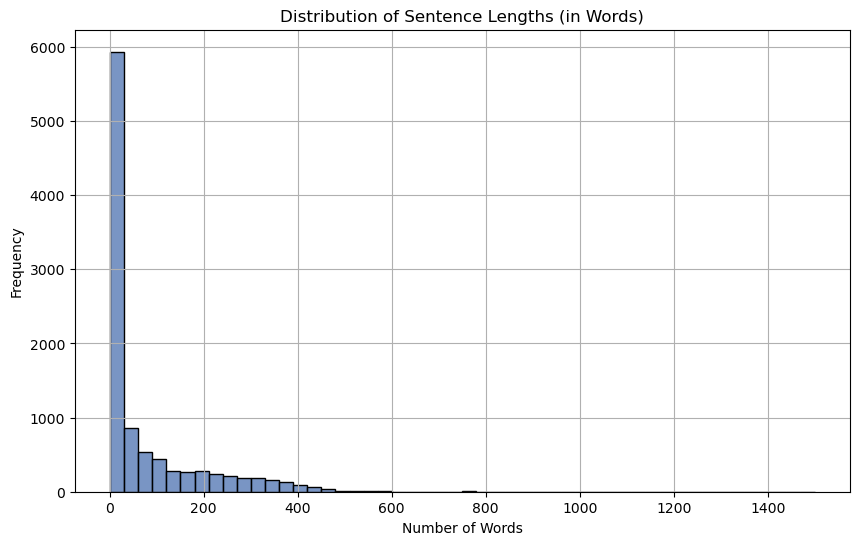

In [18]:
df_transcripts['word_count'] = df_transcripts['dialogue'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df_transcripts['word_count'], bins=50, color='#4C72B0')
plt.title('Distribution of Sentence Lengths (in Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

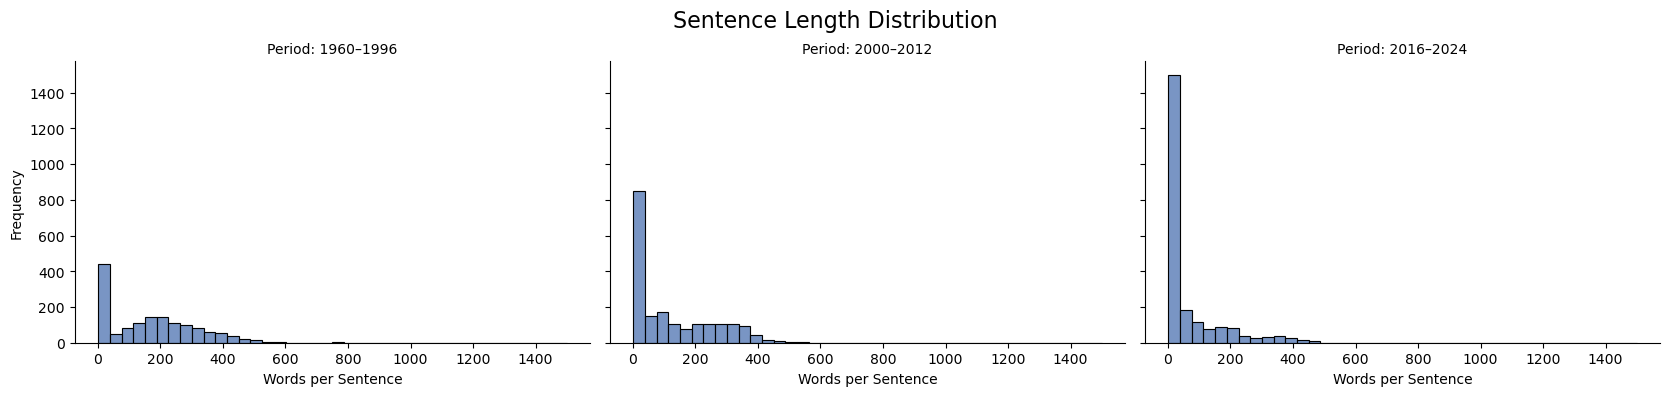

In [19]:
df_candidates = df_transcripts[df_transcripts['is_candidate'] == True].copy()
df_candidates['word_count'] = df_candidates['dialogue'].apply(lambda x: len(str(x).split()))

def map_year_block(y):
    if y < 2000:
        return "1960–1996"
    elif y <= 2012:
        return "2000–2012"
    else:
        return "2016–2024"

df_candidates['year_block'] = df_candidates['year'].apply(map_year_block)
g = sns.displot(
    data=df_candidates,
    x='word_count',
    col='year_block',
    col_order=["1960–1996", "2000–2012", "2016–2024"],
    col_wrap=3,
    height=4,
    aspect=1.4,
    bins=40,
    color='#4C72B0',
    facet_kws={'sharey': True}
)

g.set_titles("Period: {col_name}")
g.set_axis_labels("Words per Sentence", "Frequency")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Sentence Length Distribution", fontsize=16)
plt.show()

In [20]:
def assign_time_span(year):
    if year <= 1980:
        return '1960–1980'
    elif year <= 2004:
        return '1984–2004'
    else:
        return '2008–2024'

df_candidates['time_span'] = df_candidates['year'].apply(assign_time_span)

# Compute average per span
avg_per_span = df_candidates.groupby('time_span')['word_count'].mean().reset_index(name='avg_sentence_length')
print(avg_per_span)

   time_span  avg_sentence_length
0  1960–1980           296.125000
1  1984–2004           149.767279
2  2008–2024            76.431630


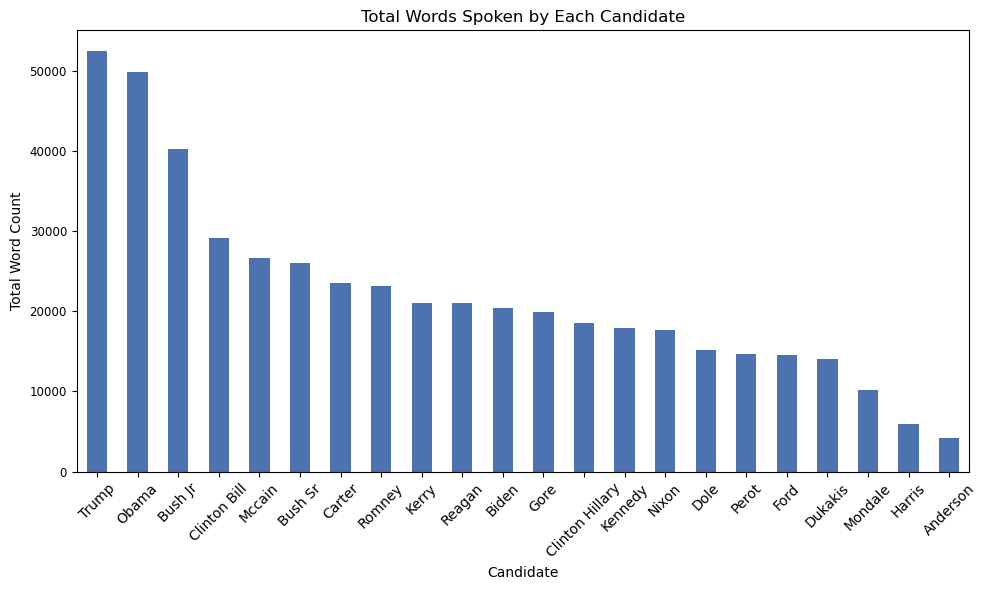

In [21]:
words_per_candidate = df_transcripts[(df_transcripts['is_candidate'] == True) & (df_transcripts['VP_debate'] == False)].groupby('actor')['word_count'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
words_per_candidate.plot(kind='bar', color='#4C72B0')
plt.title('Total Words Spoken by Each Candidate')
plt.ylabel('Total Word Count')
plt.xlabel('Candidate')
plt.xticks(rotation=45, size=10)
plt.yticks(size=8.5)
plt.tight_layout()
plt.show()

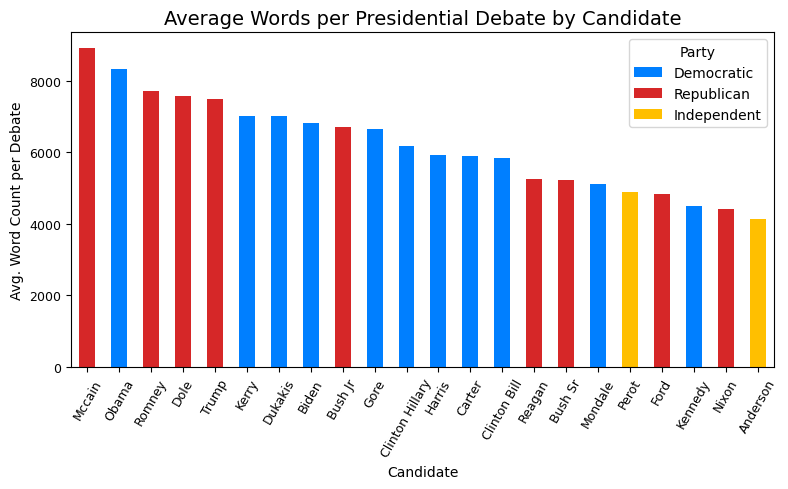

In [26]:
from matplotlib.patches import Patch

# Prep data
df_transcripts['word_count'] = df_transcripts['dialogue'].str.split().str.len()
pres_debate = df_transcripts[(df_transcripts['is_candidate']) & (~df_transcripts['VP_debate'])]

avg_words = (
    pres_debate.groupby(['actor', 'date'])['word_count'].sum()
    .groupby('actor').mean()
    .sort_values(ascending=False)
)

actor_party = pres_debate.groupby('actor')['party'].agg(lambda x: x.mode().iloc[0])

party_palette = {
    'Democratic': '#007FFF',
    'Republican': '#d62728',
    'Independent': '#FFBF00'
}

colors = [party_palette.get(actor_party.get(actor, 'Independent'), '#808080') for actor in avg_words.index]

# Plot
plt.figure(figsize=(8, 5))
avg_words.plot(kind='bar', color=colors)

plt.title('Average Words per Presidential Debate by Candidate', fontsize=14)
plt.ylabel('Avg. Word Count per Debate')
plt.xlabel('Candidate')
plt.xticks(rotation=60, fontsize=9)
plt.yticks(fontsize=9)

plt.legend(
    handles=[
        Patch(facecolor=party_palette['Democratic'], label='Democratic'),
        Patch(facecolor=party_palette['Republican'], label='Republican'),
        Patch(facecolor=party_palette['Independent'], label='Independent')
    ],
    title='Party', loc='upper right'
)

plt.tight_layout()
plt.show()

# Sentiment Analysis

### Apply VADER

In [27]:
nltk.download('vader_lexicon')
vader = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/ucloud/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [28]:
%%time
def analyze_vader(text):
    scores = vader.polarity_scores(text)
    return scores

def add_vader_sentiment(df, text_column='dialogue'):
    
    df['vader_full']= df[text_column].apply(analyze_vader)
    df['vader_sentiment'] = df['vader_full'].apply(lambda x: x['compound'])
    df['vader_label']= df['vader_sentiment'].apply(lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral'))
    return df

add_vader_sentiment(df_transcripts, 'dialogue')

CPU times: user 5.13 s, sys: 6.32 ms, total: 5.14 s
Wall time: 5.14 s


,debate_title,date,year,actor,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent,word_count,vader_full,vader_sentiment,vader_label
0,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,"Mr. Smith, Mr. Nixon. In the election of 1860,...",True,Democratic,True,False,False,1249,"{'neg': 0.074, 'neu': 0.758, 'pos': 0.169, 'co...",0.9993,positive
1,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,And now the opening statement by Vice Presiden...,False,NaN,False,False,False,11,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,neutral
2,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,"Mr. Smith, Senator Kennedy. The things that Se...",True,Republican,False,False,False,1382,"{'neg': 0.037, 'neu': 0.834, 'pos': 0.129, 'co...",0.9992,positive
3,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,"Thank you, Mr. Nixon. That completes the openi...",False,NaN,False,False,False,62,"{'neg': 0.0, 'neu': 0.961, 'pos': 0.039, 'comp...",0.3612,positive
4,1960_Kennedy_Nixon_1,1960-09-26,1960,Fleming,"Senator, the Vice President in his campaign ha...",False,NaN,False,False,False,41,"{'neg': 0.05, 'neu': 0.95, 'pos': 0.0, 'compou...",-0.2732,negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9928,2024_Vance_Walz_VP,2024-10-01,2024,Walz,"Well, thank you, Senator Vance. Thank you to C...",True,Democratic,False,True,False,391,"{'neg': 0.038, 'neu': 0.756, 'pos': 0.206, 'co...",0.9972,positive
9929,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,"Governor Walz. Thank you. Senator Vance, your ...",False,NaN,False,True,False,9,"{'neg': 0.0, 'neu': 0.762, 'pos': 0.238, 'comp...",0.3612,positive
9930,2024_Vance_Walz_VP,2024-10-01,2024,Vance,"Well, I want to thank Governor Walz, you folks...",True,Republican,True,True,False,452,"{'neg': 0.033, 'neu': 0.801, 'pos': 0.167, 'co...",0.9960,positive
9931,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,"Senator Vance, thank you. And thank you both f...",False,NaN,False,True,False,23,"{'neg': 0.0, 'neu': 0.808, 'pos': 0.192, 'comp...",0.6124,positive


### Apply RoBERTa

In [29]:
# Load model and tokenizer
model_path = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [36]:
# Shared helper: compute sentiment from logits
def compute_sentiment_from_logits(logits):
    probs = softmax(logits.detach().cpu().numpy())
    score_dict = {k: float(v) for k, v in zip(["neg", "neu", "pos"], np.round(probs, 4))}
    polarity_raw = float(np.sum(np.array([-1, 0, 1]) * probs))
    polarity_vader_scaled = float(np.tanh(2 * polarity_raw))
    return pd.Series([score_dict, polarity_raw, polarity_vader_scaled])

In [31]:
# Chunk text into overlapping slices of input_ids
def chunk_text(text, max_length=512, stride=20):
    tokens = tokenizer(text, return_tensors="pt", truncation=False)["input_ids"][0]
    return [tokens[i:i + max_length] for i in range(0, len(tokens), max_length - stride)]

In [32]:
# Sentiment for long texts using chunking
def analyze_long_text(text):
    try:
        token_chunks = chunk_text(text)
        probs_all = []

        for chunk in token_chunks:
            input_ids = chunk.unsqueeze(0)
            attention_mask = torch.ones_like(input_ids)

            with torch.no_grad():
                output = model(input_ids=input_ids, attention_mask=attention_mask)
                probs = softmax(output.logits[0].detach().cpu().numpy())
                probs_all.append(probs)

        avg_probs = np.mean(probs_all, axis=0)
        return compute_sentiment_from_logits(torch.tensor(avg_probs))

    except Exception as e:
        print("Error during long text inference:", e)
        return pd.Series([{"neg": 0.0, "neu": 1.0, "pos": 0.0}, 0.0, 0.0])

In [33]:
# Main function: choose normal or chunked analysis
def analyze_full_sentiment(text, max_length=512):
    try:
        if len(tokenizer.encode(text, truncation=False)) <= max_length:
            encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
            with torch.no_grad():
                output = model(**encoded)
            return compute_sentiment_from_logits(output.logits[0])
        else:
            return analyze_long_text(text)
    except Exception as e:
        print("Error in adaptive sentiment analysis:", e)
        return pd.Series([{"neg": 0.0, "neu": 1.0, "pos": 0.0}, 0.0, 0.0])

# DataFrame application
def add_bert_sentiment(df, text_column="dialogue"):
    df[['bert_full', 'bert_raw', 'bert_sentiment']] = df[text_column].apply(analyze_full_sentiment)
    df['bert_label'] = df['bert_sentiment'].apply(lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral'))
    return df

In [34]:
def add_diff_sentiment(df, text_column='dialogue'):
    df = add_vader_sentiment(df, text_column)
    df = add_bert_sentiment(df, text_column)
    df['diff_sentiment'] = df['vader_sentiment'] - df['bert_sentiment']
    return df

In [35]:
%%time
df_transcripts = add_diff_sentiment(df_transcripts, text_column='dialogue')

CPU times: user 3h 33min 50s, sys: 1min 27s, total: 3h 35min 17s
Wall time: 7min 15s


### See Results

In [ ]:
df_all_debates=debate_transcript_sentiment[debate_transcript_sentiment["is_candidate"]]

In [45]:
df_transcripts["debate_title"].unique()

array(['1960_Kennedy_Nixon_1', '1960_Kennedy_Nixon_2',
       '1960_Kennedy_Nixon_3', '1960_Kennedy_Nixon_4',
       '1976_Carter_Ford_1', '1976_Carter_Ford_2', '1976_Carter_Ford_3',
       '1980_Anderson_Reagan_1', '1980_Carter_Reagan_1',
       '1984_Mondale_Reagan_1', '1984_Bush Sr_Ferraro_VP',
       '1984_Mondale_Reagan_2', '1988_Bush Sr_Dukakis_1',
       '1988_Bentsen_Quayle_VP', '1988_Bush Sr_Dukakis_2',
       '1992_Bush Sr_Clinton Bill_Perot_1',
       '1992_Gore_Quayle_Stockdale_VP',
       '1992_Bush Sr_Clinton Bill_Perot_2',
       '1992_Bush Sr_Clinton Bill_Perot_3', '1996_Clinton Bill_Dole_1',
       '1996_Gore_Kemp_VP', '1996_Clinton Bill_Dole_2',
       '2000_Bush Jr_Gore_1', '2000_Cheney_Lieberman_VP',
       '2000_Bush Jr_Gore_2', '2000_Bush Jr_Gore_3',
       '2004_Bush Jr_Kerry_1', '2004_Cheney_Edwards_VP',
       '2004_Bush Jr_Kerry_2', '2004_Bush Jr_Kerry_3',
       '2008_Mccain_Obama_1', '2008_Biden_Palin_VP',
       '2008_Mccain_Obama_2', '2008_Mccain_Obama_3',

# Topic Modeling

## Preprocess Data for LDA and LDASeqModel

In [37]:
# Download only necessary resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# Initialize tools
tokenizer = TreebankWordTokenizer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Preprocessing text
def text_preprocess(text):
    if pd.isnull(text):
        return ""
    tokens = tokenizer.tokenize(text)
    filtered_tokens = [word.lower() for word in tokens if word.isalpha() and word.lower() not in stop_words]
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]
    return " ".join(lemmatized_tokens)

# Apply to your dataframe
df_transcripts["preprocessed_text"] = df_transcripts["dialogue"].apply(text_preprocess)

# Preview
df_transcripts[["dialogue", "preprocessed_text"]].head(10)

[nltk_data] Downloading package stopwords to /home/ucloud/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/ucloud/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/ucloud/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,dialogue,preprocessed_text
0,"Mr. Smith, Mr. Nixon. In the election of 1860,...",smith election abraham lincoln said question w...
1,And now the opening statement by Vice Presiden...,opening statement vice president richard nixon
2,"Mr. Smith, Senator Kennedy. The things that Se...",smith senator thing senator kennedy said many ...
3,"Thank you, Mr. Nixon. That completes the openi...",thank completes opening statement candidate an...
4,"Senator, the Vice President in his campaign ha...",senator vice president campaign said naive tim...
5,"Well, the Vice President and I came to the Con...",well vice president came congress together ser...
6,"Mr. Nixon, would you like to comment on that s...",nixon would like comment statement
7,I have no comment.,comment
8,The next question: Mr. Novins.,next question novins
9,"Mr. Vice President, your campaign stresses the...",vice president campaign stress value eight yea...


In [38]:
# Lade spaCy Modell
nlp = spacy.load("en_core_web_sm")

# Function for Filtering NOUN, ADJ, PROPN
def keep_nouns_adjectives_spacy(text):
    if pd.isnull(text):
        return ""
    doc = nlp(text)
    return " ".join([token.text.lower() for token in doc if token.pos_ in {"NOUN", "ADJ", "PROPN"}])

# Apply to DataFrame
df_transcripts["preprocessed_text"] = df_transcripts["preprocessed_text"].apply(keep_nouns_adjectives_spacy)

In [40]:
# Collect all lowercase actor names
actor_words_to_remove = set(df_transcripts['actor'].dropna().str.lower().str.strip())

# Collect all lowercase first names from your mapping
first_names_to_remove = set(name.lower() for name in CANDIDATE_FIRST_NAMES.values())

# Combine into one set of stopwords
names_to_remove = actor_words_to_remove.union(first_names_to_remove)
names_to_remove.update(["clinton", "bush"])

# Define a clean-up function
def remove_names(text):
    if pd.isnull(text):
        return text
    tokens = text.split()
    cleaned_tokens = [word for word in tokens if word.lower() not in names_to_remove]
    return " ".join(cleaned_tokens)

# Apply to proprocessed_text column
df_transcripts["preprocessed_text"] = df_transcripts["preprocessed_text"].apply(remove_names)

In [41]:
# Combine all cleaned text into one long string
all_text = " ".join(df_transcripts["preprocessed_text"].dropna())

# Split into words
words = all_text.split()

# Count frequency
word_counts = Counter(words)

# Get the 200 most common words
top_300_df = word_counts.most_common(300)

# Ensure all rows are shown
pd.set_option('display.max_rows', 300)

# Display interactively
top_300_df

[('president', 3854),
 ('people', 3375),
 ('tax', 1786),
 ('year', 1782),
 ('american', 1726),
 ('senator', 1570),
 ('country', 1529),
 ('state', 1507),
 ('time', 1394),
 ('thing', 1255),
 ('governor', 1236),
 ('job', 1021),
 ('united', 1016),
 ('way', 1002),
 ('vice', 999),
 ('america', 943),
 ('new', 894),
 ('government', 870),
 ('world', 849),
 ('good', 818),
 ('right', 808),
 ('last', 790),
 ('plan', 759),
 ('lot', 729),
 ('fact', 710),
 ('first', 693),
 ('health', 689),
 ('sure', 683),
 ('administration', 665),
 ('money', 665),
 ('care', 651),
 ('program', 625),
 ('family', 615),
 ('many', 607),
 ('security', 598),
 ('number', 585),
 ('issue', 573),
 ('war', 569),
 ('great', 548),
 ('minute', 545),
 ('work', 542),
 ('problem', 542),
 ('percent', 534),
 ('talk', 529),
 ('important', 525),
 ('policy', 520),
 ('nation', 514),
 ('kind', 513),
 ('economy', 505),
 ('business', 499),
 ('able', 498),
 ('next', 495),
 ('child', 489),
 ('federal', 489),
 ('know', 480),
 ('day', 470),
 ('cut

In [42]:
# Collect top 300 most frequent words
all_text = " ".join(df_transcripts["preprocessed_text"].dropna())
top_words = [word for word, _ in Counter(all_text.split()).most_common(300)]

# Define exception list
exception_words = {
    "tax", "job", "right", "health", "money", "care", "family", "program",
    "work", "security", "war", "business", "economy", "child", "cut", "nuclear",
    "school", "military", "woman", "budget", "social", "energy", "economic", "life",
    "law", "dollar", "education", "deal", "rate", "ill", "middle", "support",
    "weapon", "system", "cost", "drug", "young", "decision", "company", "iraq",
    "troop", "foreign", "medicare", "help", "force", "course", "oil", "defense",
    "opportunity", "soviet", "deficit", "kid", "china", "iran", "control", "increase",
    "insurance", "income", "pay", "trade", "house", "case", "power", "credit",
    "community", "word", "peace", "union", "ally", "russia", "court", "growth",
    "debt", "freedom", "effort", "use", "border", "order", "chance", "class",
    "terrorist", "college", "teacher", "action", "threat", "parent", "strength",
    "crime", "afghanistan", "arm", "call", "gun", "inflation", "member", "clean",
    "unemployment", "top", "israel", "price", "benefit", "taxpayer", "market",
    "worker", "justice", "saddam", "housing", "investment", "safe", "fund", "east",
    "russian", "sanction", "abortion", "police", "love", "regard", "fight", "lower",
    "crisis", "human", "attack", "industry", "welfare"
}

# Compute frequent words to remove (excluding exceptions)
top_words_set = set(top_words)
words_to_remove = top_words_set - exception_words

# Clean function with filtering
def clean_with_exceptions(text):
    if pd.isnull(text):
        return ""
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word.lower() not in words_to_remove]
    return " ".join(filtered_tokens)

# Apply to DataFrame
df_transcripts["preprocessed_text"] = df_transcripts["preprocessed_text"].apply(clean_with_exceptions)

# Preview result
df_transcripts[["actor", "dialogue", "preprocessed_text"]].head(10)

,actor,dialogue,preprocessed_text
0,Kennedy,"Mr. Smith, Mr. Nixon. In the election of 1860,...",abraham lincoln direction freedom direction ro...
1,Smith,And now the opening statement by Vice Presiden...,opening
2,Nixon,"Mr. Smith, Senator Kennedy. The things that Se...",discus internal affair tremendous internationa...
3,Smith,"Thank you, Mr. Nixon. That completes the openi...",completes comment anothers correspondent corre...
4,Fleming,"Senator, the Vice President in his campaign ha...",naive
5,Kennedy,"Well, the Vice President and I came to the Con...",labor program advocate century woodrow wilson ...
6,Smith,"Mr. Nixon, would you like to comment on that s...",comment
7,Nixon,I have no comment.,comment
8,Smith,The next question: Mr. Novins.,
9,Novins,"Mr. Vice President, your campaign stresses the...",stress observer participant initiator


In [43]:
# Drop rows where preprocessed_text is empty or just whitespace
df_transcripts = df_transcripts[df_transcripts["preprocessed_text"].str.strip() != ""]

# Preview the result
df_transcripts.head(10)

,debate_title,date,year,actor,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent,word_count,vader_full,vader_sentiment,vader_label,bert_full,bert_raw,bert_sentiment,bert_label,diff_sentiment,preprocessed_text
0,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,"Mr. Smith, Mr. Nixon. In the election of 1860,...",True,Democratic,True,False,False,1249,"{'neg': 0.074, 'neu': 0.758, 'pos': 0.169, 'co...",0.9993,positive,"{'neg': 0.33399999141693115, 'neu': 0.41650000...",-0.084447,-0.167306,negative,1.166606,abraham lincoln direction freedom direction ro...
1,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,And now the opening statement by Vice Presiden...,False,NaN,False,False,False,11,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,neutral,"{'neg': 0.009800000116229057, 'neu': 0.9333999...",0.046952,0.093630,positive,-0.093630,opening
2,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,"Mr. Smith, Senator Kennedy. The things that Se...",True,Republican,False,False,False,1382,"{'neg': 0.037, 'neu': 0.834, 'pos': 0.129, 'co...",0.9992,positive,"{'neg': 0.2806999981403351, 'neu': 0.409099996...",0.029422,0.058777,positive,0.940423,discus internal affair tremendous internationa...
3,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,"Thank you, Mr. Nixon. That completes the openi...",False,NaN,False,False,False,62,"{'neg': 0.0, 'neu': 0.961, 'pos': 0.039, 'comp...",0.3612,positive,"{'neg': 0.004900000058114529, 'neu': 0.4332000...",0.557028,0.805492,positive,-0.444292,completes comment anothers correspondent corre...
4,1960_Kennedy_Nixon_1,1960-09-26,1960,Fleming,"Senator, the Vice President in his campaign ha...",False,NaN,False,False,False,41,"{'neg': 0.05, 'neu': 0.95, 'pos': 0.0, 'compou...",-0.2732,negative,"{'neg': 0.6265000104904175, 'neu': 0.359499990...",-0.612626,-0.841197,negative,0.567997,naive
5,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,"Well, the Vice President and I came to the Con...",True,Democratic,True,False,False,186,"{'neg': 0.0, 'neu': 0.82, 'pos': 0.18, 'compou...",0.9856,positive,"{'neg': 0.014299999922513962, 'neu': 0.7803999...",0.191016,0.364471,positive,0.621129,labor program advocate century woodrow wilson ...
6,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,"Mr. Nixon, would you like to comment on that s...",False,NaN,False,False,False,10,"{'neg': 0.0, 'neu': 0.783, 'pos': 0.217, 'comp...",0.3612,positive,"{'neg': 0.03970000147819519, 'neu': 0.93809998...",-0.017520,-0.035025,neutral,0.396225,comment
7,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,I have no comment.,True,Republican,False,False,False,4,"{'neg': 0.524, 'neu': 0.476, 'pos': 0.0, 'comp...",-0.2960,negative,"{'neg': 0.3077999949455261, 'neu': 0.656899988...",-0.272467,-0.496714,negative,0.200714,comment
9,1960_Kennedy_Nixon_1,1960-09-26,1960,Novins,"Mr. Vice President, your campaign stresses the...",False,NaN,False,False,False,60,"{'neg': 0.047, 'neu': 0.879, 'pos': 0.074, 'co...",0.1779,positive,"{'neg': 0.013700000010430813, 'neu': 0.7706999...",0.201886,0.383172,positive,-0.205272,stress observer participant initiator
10,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,It would be rather difficult to cover them in ...,True,Republican,False,False,False,270,"{'neg': 0.016, 'neu': 0.874, 'pos': 0.11, 'com...",0.9749,positive,"{'neg': 0.09839999675750732, 'neu': 0.82359999...",-0.020330,-0.040637,neutral,1.015537,difficult foreign trip recommendation trip inc...


In [46]:
# Filter for Trump speeches only
df_trump = df_transcripts[df_transcripts["actor"] == "Trump"].copy()

# Tokenize Trump's preprocessed text
df_trump["tokens"] = df_trump["preprocessed_text"].apply(lambda x: x.split())

# Group by year and sort
grouped_trump = df_trump.groupby("year")["tokens"].apply(list).sort_index()

# Flatten into one document per speech
all_docs_trump = [doc for year_docs in grouped_trump for doc in year_docs]

# One time slice per year = number of Trump speeches that year
timeslices_trump = [len(year_docs) for year_docs in grouped_trump]

# Create dictionary and BoW corpus
dictionary_trump = corpora.Dictionary(all_docs_trump)
corpus_trump = [dictionary_trump.doc2bow(text) for text in all_docs_trump]

In [47]:
topic_range = range(3, 21)
coherence_scores = []

for num_topics in topic_range:
    lda_model_trump = LdaModel(
        corpus=corpus_trump,
        id2word=dictionary_trump,
        num_topics=num_topics,
        passes=35,
        random_state=42
    )
    coherence_model = CoherenceModel(
        model=lda_model_trump,
        corpus=corpus_trump,
        dictionary=dictionary_trump,
        coherence='u_mass'
    )
    coherence_trump = coherence_model.get_coherence()
    coherence_scores_trump.append(coherence_trump)
    print(f"Topics: {num_topics}, UMass Coherence: {coherence:.4f}")

Topics: 3, UMass Coherence: -11.2976
Topics: 4, UMass Coherence: -11.7729
Topics: 5, UMass Coherence: -12.5094
Topics: 6, UMass Coherence: -13.1698
Topics: 7, UMass Coherence: -12.8585
Topics: 8, UMass Coherence: -13.4561
Topics: 9, UMass Coherence: -12.9580
Topics: 10, UMass Coherence: -13.3368
Topics: 11, UMass Coherence: -13.3522
Topics: 12, UMass Coherence: -13.5135
Topics: 13, UMass Coherence: -13.9611
Topics: 14, UMass Coherence: -14.1731
Topics: 15, UMass Coherence: -13.9286
Topics: 16, UMass Coherence: -13.7672
Topics: 17, UMass Coherence: -13.8026
Topics: 18, UMass Coherence: -14.3612
Topics: 19, UMass Coherence: -14.3917
Topics: 20, UMass Coherence: -14.2594


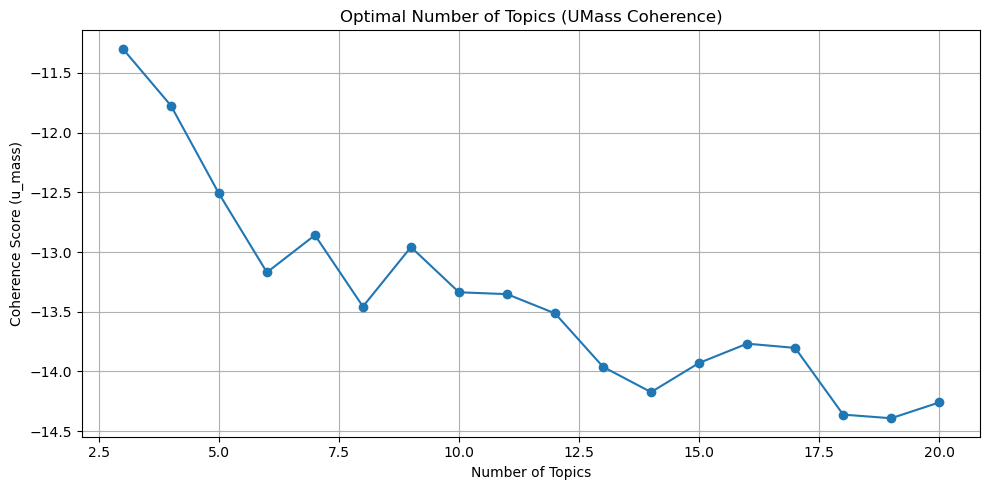

In [48]:
plt.figure(figsize=(10, 5))
plt.plot(topic_range, coherence_scores, marker='o')
plt.title("Optimal Number of Topics (UMass Coherence)")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (u_mass)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [59]:
# Train LDA model on Trump's speeches
lda_trump = LdaModel(
    corpus=corpus_trump,
    id2word=dictionary_trump,
    num_topics=5,     
    passes=100,
    random_state=42
)

In [60]:
# Display the 5 topics with their top 10 words
for i in range(lda_trump.num_topics):
    print(f"Topic {i}:")
    print(lda_trump.print_topic(i, topn=10))
    print()

Topic 0:
0.025*"border" + 0.014*"job" + 0.014*"tax" + 0.011*"justice" + 0.011*"drug" + 0.010*"care" + 0.008*"obamacare" + 0.008*"horrible" + 0.008*"fire" + 0.008*"woman"

Topic 1:
0.023*"law" + 0.021*"company" + 0.016*"worst" + 0.016*"job" + 0.012*"energy" + 0.011*"money" + 0.009*"trade" + 0.009*"chicago" + 0.008*"order" + 0.007*"middle"

Topic 2:
0.021*"job" + 0.013*"china" + 0.013*"ill" + 0.008*"economy" + 0.008*"pelosi" + 0.008*"nancy" + 0.007*"money" + 0.007*"iran" + 0.007*"shut" + 0.007*"politician"

Topic 3:
0.029*"money" + 0.026*"russia" + 0.024*"dollar" + 0.012*"deal" + 0.011*"iran" + 0.010*"isi" + 0.009*"right" + 0.009*"bernie" + 0.008*"care" + 0.008*"china"

Topic 4:
0.032*"war" + 0.016*"tax" + 0.009*"baby" + 0.009*"china" + 0.008*"disaster" + 0.007*"chris" + 0.007*"forest" + 0.007*"pennsylvania" + 0.007*"building" + 0.006*"putin"



In [56]:
# Define list of target actors
actors_focus = ["Harris", "Biden", "Clinton Hillary"]

# Filter rows for these actors
df_selected = df_transcripts[df_transcripts["actor"].isin(actors_focus)].copy()

# Tokenize preprocessed text
df_selected["tokens"] = df_selected["preprocessed_text"].apply(lambda x: x.split())

# Group tokenized speeches by year and sort chronologically
grouped_selected = df_selected.groupby("year")["tokens"].apply(list).sort_index()

# Flatten into one document per speech
all_docs_selected = [doc for year_docs in grouped_selected for doc in year_docs]

# Count number of speeches per year
timeslices_selected = [len(year_docs) for year_docs in grouped_selected]

# Create dictionary and BoW corpus
dictionary_selected = corpora.Dictionary(all_docs_selected)
corpus_selected = [dictionary_selected.doc2bow(text) for text in all_docs_selected]

In [58]:
from gensim.models import LdaModel

lda_selected = LdaModel(
    corpus=corpus_selected,
    id2word=dictionary_selected,
    num_topics=5,
    passes=100,
    random_state=42
)

# Show topics
for i in range(lda_selected.num_topics):
    print(f"Topic {i}:")
    print(lda_selected.print_topic(i, topn=10))
    print()

🗣️ Topic 0:
0.033*"tax" + 0.019*"care" + 0.018*"health" + 0.016*"woman" + 0.015*"family" + 0.012*"business" + 0.012*"right" + 0.010*"insurance" + 0.009*"money" + 0.009*"cut"

🗣️ Topic 1:
0.011*"police" + 0.009*"money" + 0.008*"court" + 0.007*"law" + 0.007*"community" + 0.007*"ill" + 0.007*"justice" + 0.006*"criminal" + 0.006*"work" + 0.006*"help"

🗣️ Topic 2:
0.016*"war" + 0.014*"security" + 0.010*"china" + 0.010*"job" + 0.009*"nuclear" + 0.009*"putin" + 0.008*"military" + 0.008*"ally" + 0.008*"trade" + 0.007*"intelligence"

🗣️ Topic 3:
0.025*"job" + 0.013*"energy" + 0.011*"clean" + 0.010*"deal" + 0.009*"oil" + 0.009*"climate" + 0.007*"work" + 0.006*"kid" + 0.006*"economy" + 0.006*"manufacturing"

🗣️ Topic 4:
0.031*"tax" + 0.018*"middle" + 0.015*"court" + 0.012*"cut" + 0.012*"class" + 0.010*"wealthy" + 0.009*"work" + 0.008*"support" + 0.007*"ballot" + 0.006*"gun"



## Dynamic Topic Modeling using LDASeqModel() from Gensim

In [ ]:
topic_range = range(3, 21)
coherence_scores = []

for num_topics in topic_range:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=35,
        random_state=42
    )
    coherence_model = CoherenceModel(
        model=lda_model,
        corpus=corpus,
        dictionary=dictionary,
        coherence='u_mass'
    )
    coherence = coherence_model.get_coherence()
    coherence_scores.append(coherence)
    print(f"Topics: {num_topics}, UMass Coherence: {coherence:.4f}")

## Topic Modeling using KeyBERT and BERTopic